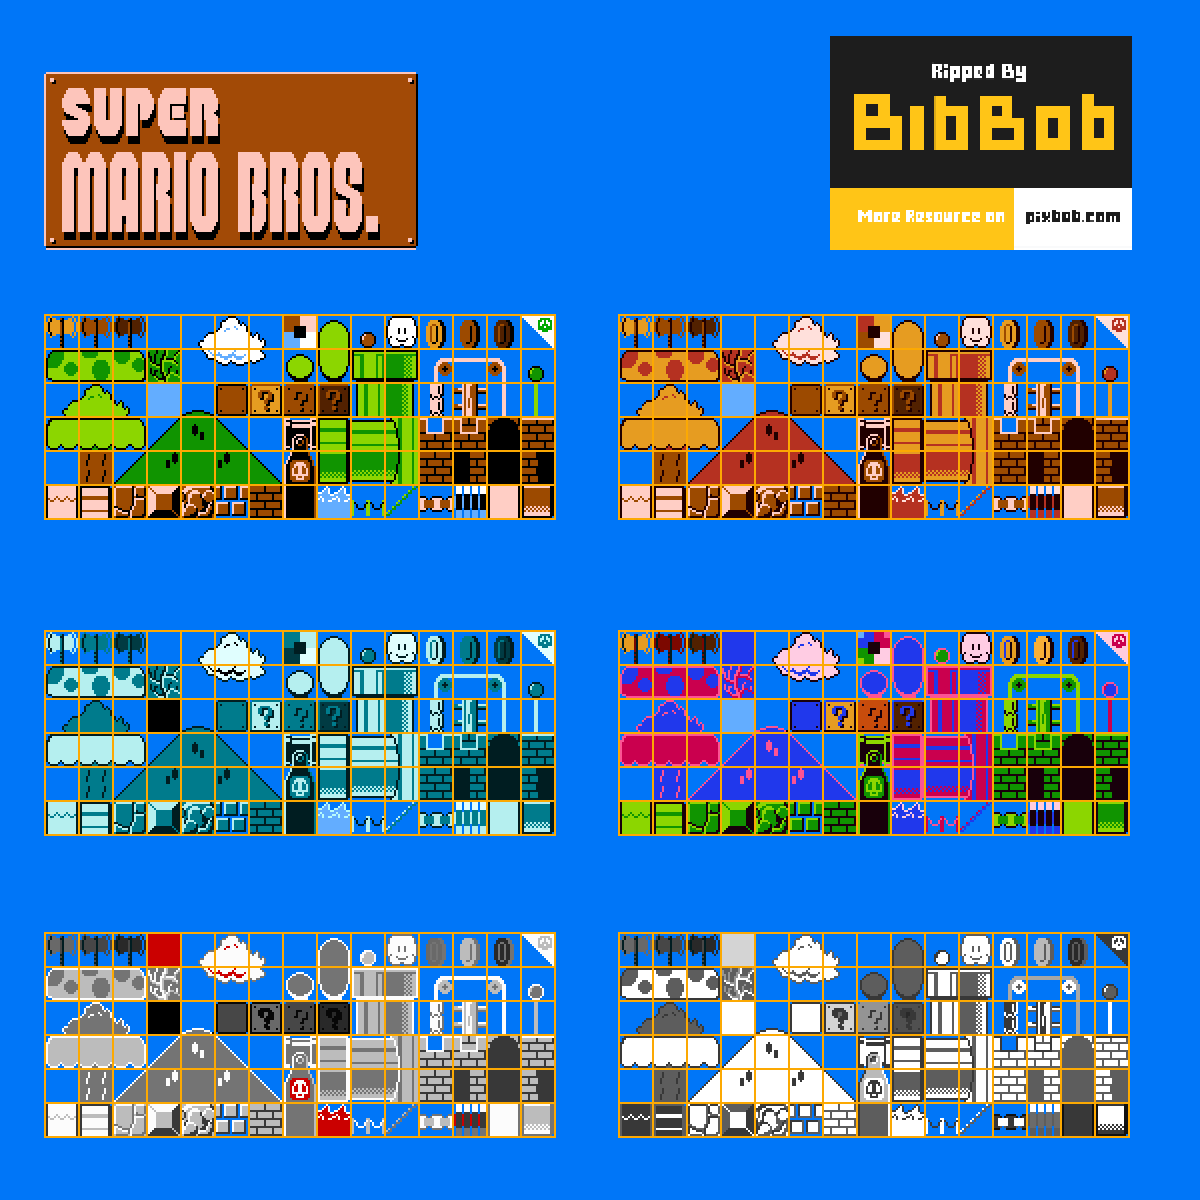



> Agregar bloque entrecomillado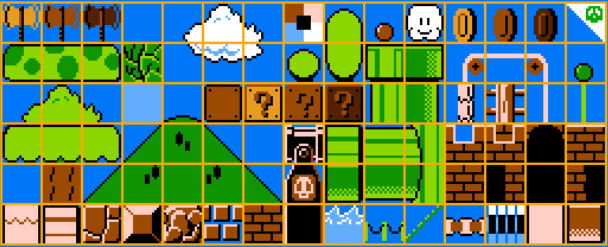



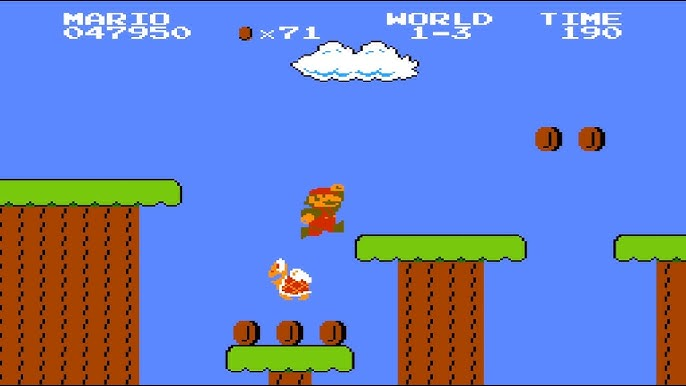

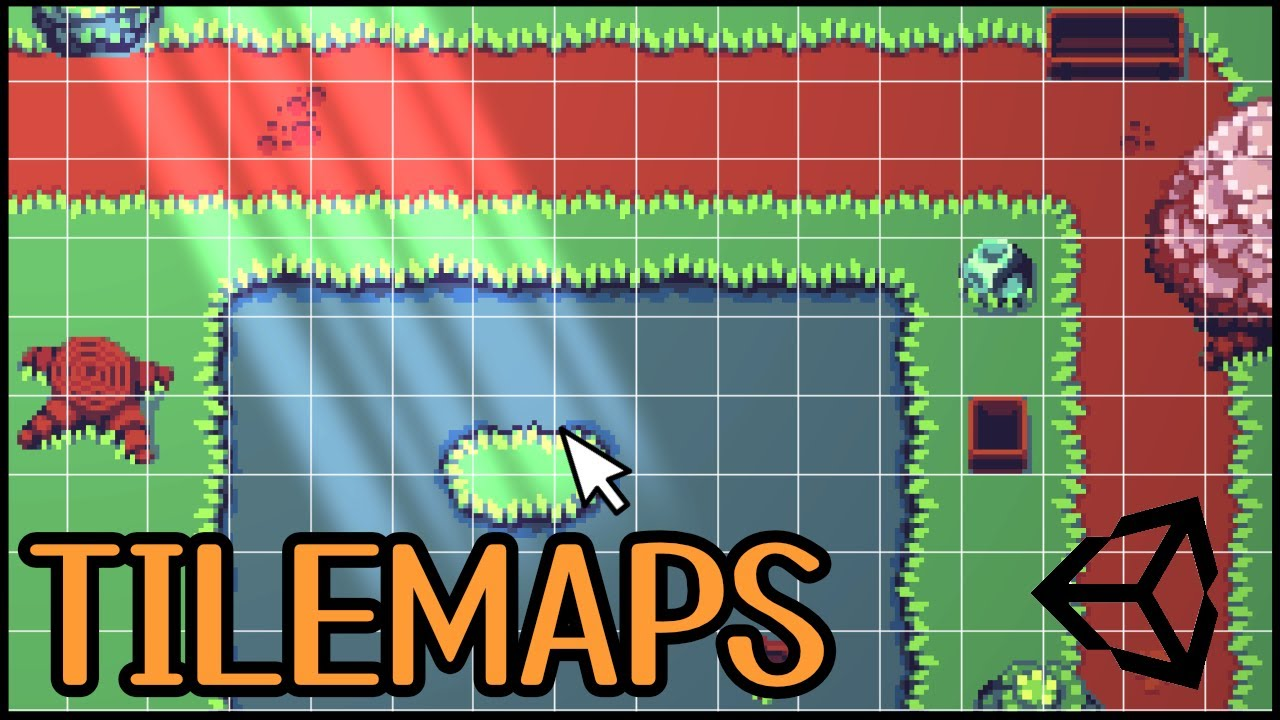

Tile maps:
https://thorbjorn.itch.io/tiled/download/eyJpZCI6Mjg3NjgsImV4cGlyZXMiOjE3NTkzMjIyNjh9.hU9a2yMHj3imtwhBgd%2bA4VBcwbw%3d

https://tilemap.pixlab.io/

Sprite sheets:
https://www.deviantart.com/tallcheeto14/art/overhauled-mario-sprite-sheet-vol-1-978323842

pikpng.com/pngvi/wbmRmb_mario-sprites-fw-snes-koopa-troopa-super-mario-world-sprite-clipart/

vhv.rs/viewpic/wmmmim_mario-sprite-sheet-png-transparent-png/

pikpng.com/transpng/wbmRxJ/



### **Clase Técnica: Construcción de un Juego de Plataformas Completo**

**Objetivo:**
Desarrollar un juego de plataformas 2D con un personaje animado, un nivel con scroll diseñado en Tiled, y una estructura de juego completa (menú, vidas, enemigos, power-ups, fin de juego) utilizando el motor modular previamente construido.

-----

### **1. Arquitectura del Software: GameLoop vs. Gestor de Escenas**

  * **El `GameLoop` (El Ejecutor):** La clase principal del juego (`PlatformerGame`) contiene el `GameLoop`. Su responsabilidad es mantener el ciclo de ejecución a 60 FPS y delegar las tres tareas principales en cada ciclo: manejar eventos, actualizar el estado y dibujar en pantalla. Es el proceso persistente que corre el juego.

  * **El Gestor de Escenas (El Delegador):** Este patrón, implementado en `PlatformerGame`, utiliza un diccionario de escenas (`self.scenes`) y una referencia a la escena activa (`self.current_scene`). El `GameLoop` no ejecuta la lógica del juego directamente, sino que invoca los métodos (`.update()`, `.draw()`, etc.) de la escena activa. Esto permite una organización modular.

**Flujo de Lógica:**

1.  **Bucle Principal:** Se ejecuta en el método `run()` de la clase `PlatformerGame`.
2.  **Lógica de Escena:** La lógica específica de la pantalla actual (menú, juego) se ejecuta en los métodos `update()` y `draw()` de la clase de escena correspondiente (`MenuScene`, `GameScene`).
3.  **Lógica de Físicas y Colisiones:** La simulación de gravedad y la detección de choques residen en el método `update()` de las entidades (`Player`, `Enemy`), que es invocado por el `update()` de la `GameScene`.

-----

### **2. Uso del Motor: Componentes y Funcionalidad**

La siguiente tabla resume los componentes del motor y su aplicación en este proyecto.

| Módulo del Engine | Clase/Función Principal | Propósito y Cómo el Estudiante Debe Usarlo |
| :--- | :--- | :--- |
| `asset_manager.py` | `AssetManager` | **Propósito:** Centralizar la carga de todos los recursos (imágenes, sonidos, spritesheets).<br>**Uso:** Instanciar en `game.py`. Llamar a `assets.load_spritesheet()` para cargar el `mario.json` y a `assets.load_sound()` para los archivos de audio. |
| `camera.py` | `Camera` | **Propósito:** Gestionar el scroll del nivel.<br>**Uso:** Instanciar en `game_scene.py`. En `update()`, llamar a `camara.update(jugador)`. En `draw()`, usar `camara.apply(sprite)` al dibujar cada sprite. |
| `game_object.py` | `GameObject` | **Propósito:** Clase base para todas las entidades visuales con animación.<br>**Uso:** Todas las entidades (`Player`, `Enemy`, `PowerUp`) deben heredar de esta clase. Proporciona `self.image`, `self.rect` y la lógica de animación. |
| `spritesheet.py` | `Spritesheet` | **Propósito:** Leer los archivos `.json` generados por el editor de sprites.<br>**Uso:** Es utilizado **internamente** por el `AssetManager`. El estudiante no interactúa con él directamente. |
| `tilemap.py` | `TilemapLoader` | **Propósito:** Leer los archivos `.json` exportados por **Tiled**.<br>**Uso:** Instanciar en `game_scene.py` y llamar a `loader.load_level()`. Devuelve los grupos de sprites y las propiedades del mundo. |
| `ui.py` | `Scene`, `Button` | **Propósito:** Estructurar el juego en escenas (pantallas) y crear botones.<br>**Uso:** `MenuScene`, `GameScene`, etc., heredan de `Scene`. `MenuScene` usa `Button` para la opción "Jugar". |
| **Manejo de Colisiones** | `tilemap.py` + `entities/player.py` | **Propósito:** Detectar y reaccionar a los choques entre el jugador y el mundo.<br>**Uso (3 Pasos):**<br>1. **En Tiled:** Nombrar la capa de plataformas con el sufijo `_colision` (ej: `Plataformas_colision`).<br>2. **Motor:** `TilemapLoader` lee el nombre y añade automáticamente los tiles de esa capa al grupo `collision_sprites`.<br>3. **Juego:** El método `update()` del `Player` recibe este grupo y lo usa con `pygame.sprite.spritecollide()` para resolver los choques. |

-----

### **3. Procedimiento de Creación del Juego (Paso a Paso)**

#### **Paso 1: Configuración de Assets y Proyecto**

Asegúrese de que la estructura de carpetas y los archivos de assets requeridos estén en su lugar.

  * **Estructura:**
    ```
    /platformer/
    |-- assets/
    |   |-- sprites/
    |   |   |-- mario.json
    |   |   |-- mario_spritesheet.png
    |   |   |-- nivel_1.json
    |   |   |-- mario_tileset.png
    |   |
    |   |-- audio/
    |       |-- jump.wav
    |       |-- stomp.wav
    |       |-- hit.wav
    |       |-- powerup.wav
    |       |-- music.ogg
    |
    |-- scenes/
    |-- entities/
    |-- game.py
    |-- main.py
    ```

#### **Paso 2: Diseño del Nivel en Tiled**

1.  **Nuevo Mapa y Tileset:** Cree un nuevo mapa en Tiled (ej: 200x20 tiles de 16x16 px) y añada su `mario_tileset.png` como un nuevo tileset.
2.  **Crear Capas:**
      * Una `Capa de Patrones` llamada **`Plataformas_colision`**.
      * Una `Capa de Objetos` llamada **`Entidades`**.
3.  **Pintar Nivel:** Pinte el suelo y las plataformas en la capa `Plataformas_colision`.
4.  **Posicionar Entidades:** En la capa `Entidades`, use la herramienta **"Insertar Patrón" (T)** para colocar:
      * **Jugador:** Coloque un objeto y dele el **Nombre** `player_start`.
      * **Enemigos:** Coloque un sprite de enemigo y asígnele el **Tipo** `enemy`.
      * **Power-ups:** Coloque un sprite de power-up y asígnele el **Tipo** `powerup`.
5.  **Incrustar y Exportar:**
      * Vaya a `Archivo > Propiedades del mapa...` y marque **"Incrustar conjunto de patrones en el mapa"**.
      * Vaya a `Archivo > Exportar como...` y guarde el mapa como `nivel_1.json` en `platformer/assets/sprites/`.

#### **Paso 3: El Código Completo del Juego**

Aquí se presentan los archivos de código completos y funcionales para el proyecto `platformer`.

##### **`platformer/entities/player.py`**

```python
import pygame
from engine.game_object import GameObject

class Player(GameObject):
    def __init__(self, x, y, assets):
        self.assets = assets
        self.animations = {
            'idle': self.assets.get_animation('player_ss', 'idle'),
            'walk_right': self.assets.get_animation('player_ss', 'walk_right'),
            'walk_left': self.assets.get_animation('player_ss', 'walk_left')
        }
        super().__init__(x, y, self.animations['idle'])
        
        self.velocidad_mov = 5; self.fuerza_salto = 16; self.gravedad = 0.7
        self.pos = pygame.math.Vector2(x, y); self.vel = pygame.math.Vector2(0, 0)
        self.en_suelo = False; self.current_animation_name = 'idle'
        self.vidas = 3; self.is_invincible = False; self.invincible_timer = 0

    def set_animation(self, anim_name):
        if self.current_animation_name != anim_name:
            self.current_animation_name = anim_name
            self.frames = self.animations[anim_name]
            self.current_frame = 0

    def update(self, plataformas, *args, **kwargs):
        self.vel.x = 0
        teclas = pygame.key.get_pressed()
        if teclas[pygame.K_LEFT]:
            self.vel.x = -self.velocidad_mov; self.set_animation('walk_left')
        elif teclas[pygame.K_RIGHT]:
            self.vel.x = self.velocidad_mov; self.set_animation('walk_right')
        else:
            self.set_animation('idle')
        if teclas[pygame.K_SPACE] and self.en_suelo:
            self.vel.y = -self.fuerza_salto; self.en_suelo = False; kwargs.get('audio_manager').play_sound('jump')
        
        self.vel.y += self.gravedad
        if self.vel.y > 20: self.vel.y = 20
        self.pos.x += self.vel.x; self.rect.centerx = round(self.pos.x)
        self.check_collision_x(plataformas)
        self.pos.y += self.vel.y; self.rect.centery = round(self.pos.y)
        self.check_collision_y(plataformas)
        
        if self.is_invincible:
            self.invincible_timer -= 1
            if self.invincible_timer <= 0: self.is_invincible = False
        
        super().update()
        self.image = pygame.transform.scale(self.image, (32, 32))
        self.rect = self.image.get_rect(center=self.rect.center)

    def check_collision_x(self, plataformas):
        colisiones = pygame.sprite.spritecollide(self, plataformas, False)
        for plat in colisiones:
            if self.vel.x > 0: self.rect.right = plat.rect.left
            elif self.vel.x < 0: self.rect.left = plat.rect.right
            self.pos.x = self.rect.centerx

    def check_collision_y(self, plataformas):
        colisiones = pygame.sprite.spritecollide(self, plataformas, False)
        self.en_suelo = False
        for plat in colisiones:
            if self.vel.y > 0:
                self.rect.bottom = plat.rect.top; self.en_suelo = True; self.vel.y = 0
            elif self.vel.y < 0:
                self.rect.top = plat.rect.bottom; self.vel.y = 0
            self.pos.y = self.rect.centery
            
    def hit(self):
        if self.is_invincible: return False
        self.vidas -= 1; self.is_invincible = True; self.invincible_timer = 120
        self.pos.x, self.pos.y = 150, 200; self.vel.y = 0
        return True
```

*(Crea también los archivos `enemy.py` y `powerup.py` como en la clase anterior)*

##### **`platformer/scenes/game_scene.py`**

```python
import pygame
import os
from engine.ui import Scene
from engine.camera import Camera
from engine.tilemap import TilemapLoader
from platformer.entities.player import Player

class GameScene(Scene):
    def __init__(self, game):
        super().__init__(game)
        loader = TilemapLoader(self.game.assets)
        level_path = os.path.join(self.game.assets_dir, 'nivel_1.json')
        result = loader.load_level(level_path)
        
        if result is None: self.game.running = False; return
            
        self.sprite_groups, world_w, world_h, player_start_pos = result
        self.jugador = Player(player_start_pos[0], player_start_pos[1], self.game.assets)
        self.sprite_groups["all_sprites"].add(self.jugador)
        self.camara = Camera(self.game.screen.get_width(), self.game.screen.get_height(), world_w, world_h)
        self.game.audio_manager.play_music()

    def update(self):
        if not self.game.running: return
        self.sprite_groups["all_sprites"].update(plataformas=self.sprite_groups["collision_sprites"], audio_manager=self.game.audio_manager)
        self.camara.update(self.jugador)

        enemigos_tocados = pygame.sprite.spritecollide(self.jugador, self.sprite_groups['enemies'], False)
        if enemigos_tocados:
            if self.jugador.vel.y > 0 and self.jugador.rect.bottom < enemigos_tocados[0].rect.centery + 10:
                enemigos_tocados[0].kill(); self.jugador.vel.y = -10
                self.game.audio_manager.play_sound('stomp')
            else:
                if self.jugador.hit(): self.game.audio_manager.play_sound('hit')
        
        if self.jugador.rect.top > self.game.screen.get_height() + 50:
            if self.jugador.hit(): self.game.audio_manager.play_sound('hit')

        if self.jugador.vidas <= 0:
            self.game.change_scene('game_over')
            self.game.audio_manager.stop_music()

    def draw(self, surface):
        if not self.game.running: return
        surface.fill((107, 140, 255))
        for sprite in self.sprite_groups["all_sprites"]:
            surface.blit(sprite.image, self.camara.apply(sprite))
        
        font = pygame.font.Font(None, 36)
        lives_text = font.render(f"Vidas: {self.jugador.vidas}", True, (255,255,255))
        surface.blit(lives_text, (10, 10))
            
    def handle_events(self, events):
        pass
```

*(Recuerda crear también `menu_scene.py` y `game_over_scene.py`)*

##### **`platformer/game.py`**

```python
import pygame
import os
from engine.asset_manager import AssetManager
from engine.audio import AudioManager
from platformer.scenes.menu_scene import MenuScene
from platformer.scenes.game_scene import GameScene
from platformer.scenes.game_over_scene import GameOverScene

class PlatformerGame:
    def __init__(self):
        pygame.init()
        self.screen = pygame.display.set_mode((1024, 600))
        pygame.display.set_caption("Plataformero con Engine Profesional")
        self.clock = pygame.time.Clock()
        self.running = True
        self.game_dir = os.path.dirname(__file__); self.assets_dir = os.path.join(self.game_dir, 'assets')
        self.assets = AssetManager(); self.audio_manager = AudioManager()
        self.load_assets()
        
        if self.running:
            self.scenes = {'menu': MenuScene(self), 'game': GameScene(self), 'game_over': GameOverScene(self)}
            self.current_scene = self.scenes['menu']

    def load_assets(self):
        try:
            sprites_dir = os.path.join(self.assets_dir, 'sprites')
            audio_dir = os.path.join(self.assets_dir, 'audio')
            self.assets.load_spritesheet('player_ss', os.path.join(sprites_dir, 'mario.json'))
            self.audio_manager.load_sound('jump', os.path.join(audio_dir, 'jump.wav'))
            self.audio_manager.load_sound('stomp', os.path.join(audio_dir, 'stomp.wav'))
            self.audio_manager.load_sound('hit', os.path.join(audio_dir, 'hit.wav'))
            self.audio_manager.load_sound('powerup', os.path.join(audio_dir, 'powerup.wav'))
            self.audio_manager.load_music(os.path.join(audio_dir, 'music.ogg'))
        except Exception as e:
            print(f"Error fatal al cargar assets: {e}"); self.running = False
            
    def run(self):
        if not self.running: return
        while self.running:
            events = pygame.event.get()
            for event in events:
                if event.type == pygame.QUIT: self.running = False
            self.current_scene.handle_events(events)
            self.current_scene.update()
            self.current_scene.draw(self.screen)
            pygame.display.flip()
            self.clock.tick(60)
        pygame.quit()

    def change_scene(self, scene_name):
        if scene_name == 'game': self.scenes['game'] = GameScene(self)
        self.current_scene = self.scenes.get(scene_name)
```

##### **`platformer/main.py`**

```python
from platformer.game import PlatformerGame
def main():
    juego = PlatformerGame(); juego.run()
if __name__ == '__main__':
    main()
```